In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
import matplotlib.pyplot as plt
import pickle
import numpy as np

import sinter
import os, pickle
import numpy as np

from qecsim.lattice_surgery.circuit import surgery_circuit
from qecsim.threshold_num.calc_threshold_new import calc_threshold_new
from qecsim.threshold_num.calc_threshold import threshold_approx

Adding the Observables manually doesn't really work. Stim therefore has a function called solve_flow_measurements:
<br>
<br>
    -> Implements the observables who satisfy needed flow i.e. X1 -> X1X2 in the normal CX case
<br>
    -> Keeps the corrective CZ/CX gates in mind

In [5]:
test = surgery_circuit(distance = 3, round_num = 2,target_state_init="X+", control_state_init="X+", flow_observable = "X -> XX")

In [4]:
#Loading Stats with pickle
with open("lscx_normrounds.pkl", "rb") as file:
    stats_norm = pickle.load(file)
with open("lscx_doublerounds.pkl", "rb") as file:
    stats_double = pickle.load(file)
with open("lscx_threerounds.pkl", "rb") as file:
    stats_3 = pickle.load(file)

In [5]:
distances = sorted(set(stat.json_metadata["distance"] for stat in stats_norm))

print(distances)

red_dict_norm : dict = {}
red_dict_double : dict = {}
red_dict_3 : dict = {}

for d in range(0,len(distances)-1):
    red_dict_norm[distances[d]] = [stat for stat in stats_norm if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_double[distances[d]] = [stat for stat in stats_double if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]
    red_dict_3[distances[d]] = [stat for stat in stats_3 if stat.json_metadata["distance"] in {distances[d], distances[d+1]}]

[3, 5, 7, 9, 11, 13, 15, 17]


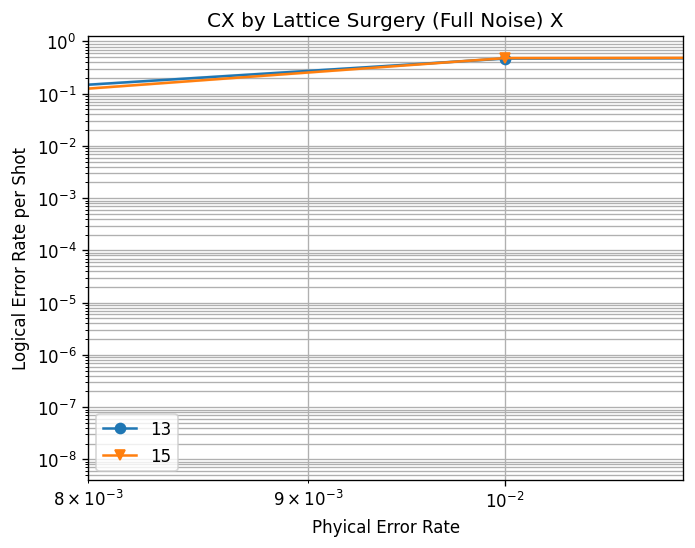

In [28]:
##################
# Plotting X Noise
##################

fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=red_dict_norm[13],
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'])
ax.loglog()
ax.set_xlim(0.8e-2, 1.1e-2)
ax.set_title("CX by Lattice Surgery (Full Noise) X")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

In [ ]:
threshold_approx(red_dict_norm[13], p_min = 0.007, p_max = 0.017)

error: (m>k) failed for hidden m: fpcurf0:m=2

: 

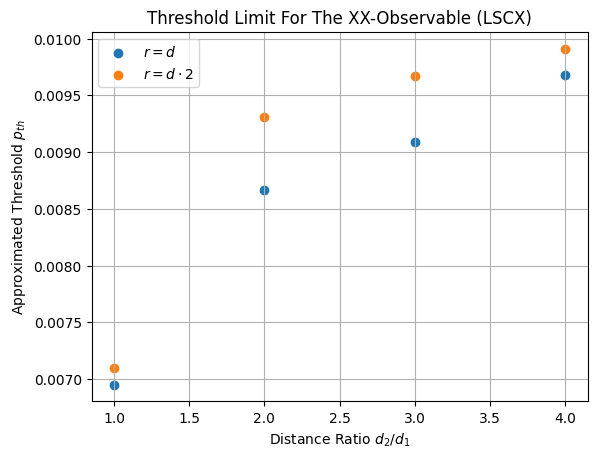

In [ ]:
data_array_norm = []
data_array_double = []
data_array_3 = []

for pos, i in enumerate(distances[:-1]):
    try:
        data_array_norm.append([threshold_(red_dict_norm[i]), pos + 1])
    except Exception:
        continue
    try:
        data_array_double.append([calc_threshold_new(red_dict_double[i]), pos + 1])
    except Exception:
        continue
    try:
        data_array_3.append([calc_threshold_new(red_dict_3[i]), pos + 1])
    except Exception:
        continue


x_vals_norm = [point[1] for point in data_array_norm[:-1]]
y_vals_norm = [point[0] for point in data_array_norm[:-1]]
x_vals_double = [point[1] for point in data_array_double]
y_vals_double = [point[0] for point in data_array_double]
x_vals_3 = [point[1] for point in data_array_3[:-1]]
y_vals_3 = [point[0] for point in data_array_3[:-1]]


plt.scatter(x_vals_norm, y_vals_norm, label = "$r=d$")
plt.scatter(x_vals_double, y_vals_double, label = "$r = d \\cdot 2$")
#plt.scatter(x_vals_3, y_vals_3, label = "r = 3")
plt.ylabel("Approximated Threshold $p_{th}$")
plt.xlabel("Distance Ratio $d_2/d_1$")
plt.title("Threshold Limit For The XX-Observable (LSCX)")
plt.legend()
plt.grid(True)

In [41]:
#Loading Stats with pickle
with open("lattice_surgery_measurement_noise_full_X.pkl", "rb") as file:
    stats_noisy_X = pickle.load(file)

In [ ]:
#Loading Stats with pickle
with open("lattice_surgery_measurement_noise_full_XX.pkl", "rb") as file:
    stats_noisy_XX = pickle.load(file)

In [ ]:
#Loading Stats with pickle
with open("lattice_surgery_measurement_noise_full_Z.pkl", "rb") as file:
    stats_noisy_Z = pickle.load(file)

In [ ]:
#Loading Stats with pickle
with open("lattice_surgery_measurement_noise_full_ZZ.pkl", "rb") as file:
    stats_noisy_ZZ = pickle.load(file)